In [5]:
import pandas as pd

mocap_df = pd.read_csv('./datasets/gait_features.csv').drop(columns=['participant'])
mocap_stats = mocap_df.describe().T
mocap_stats['cv'] = mocap_stats['std'] / mocap_stats['mean'] * 100
mocap_stats

,count,mean,std,min,25%,50%,75%,max,cv
l_mean_stride_time,152.0,1.173509,0.130922,0.946667,1.066667,1.140000,1.243333,1.573333,11.156486
r_mean_stride_time,152.0,1.176031,0.135992,0.940000,1.080000,1.140000,1.243333,1.613333,11.563607
total_mean_stride_time,152.0,1.175301,0.131941,0.960000,1.073000,1.144000,1.240000,1.568000,11.226181
l_mean_stride_dist,152.0,1400.133140,156.448341,1018.948789,1299.005208,1398.389587,1486.201502,1879.577304,11.173819
r_mean_stride_dist,152.0,1413.747790,149.816462,1070.896634,1316.573449,1424.600781,1498.970634,1925.379027,10.597114
total_mean_stride_dist,152.0,1403.732863,148.001177,1101.507206,1302.114814,1404.788706,1483.108147,1910.111786,10.543400
l_r_mean_step_times,152.0,0.601816,0.065522,0.466667,0.556667,0.600000,0.640000,0.800000,10.887409
r_l_mean_step_times,152.0,0.578443,0.081448,0.440000,0.520000,0.560000,0.630000,0.810000,14.080621
total_mean_step_times,152.0,0.591007,0.066480,0.480000,0.542143,0.576000,0.632000,0.786667,11.248640
l_r_mean_step_dist,152.0,710.085574,79.079638,489.157589,656.457642,707.239895,759.578544,964.169659,11.136635


In [6]:
triang_df = pd.read_csv('./datasets/triangulation_gait_features.csv').drop(columns=['participant'])
triang_stats = triang_df.describe().T
triang_stats['cv'] = triang_stats['std'] / triang_stats['mean'] * 100
triang_stats

,count,mean,std,min,25%,50%,75%,max,cv
l_mean_stride_time,150.0,1.132356,0.140676,0.800000,1.040000,1.100000,1.225000,1.560000,12.423276
r_mean_stride_time,150.0,1.115067,0.169439,0.680000,1.000000,1.080000,1.225000,1.680000,15.195415
total_mean_stride_time,150.0,1.124174,0.143338,0.820000,1.027500,1.100000,1.215333,1.620000,12.750520
l_mean_stride_dist,150.0,1402.515302,166.409646,977.693739,1299.172865,1392.533801,1499.013797,1920.981704,11.865086
r_mean_stride_dist,150.0,1410.978283,154.769674,1042.761954,1303.231904,1411.909094,1493.487657,1903.704899,10.968962
total_mean_stride_dist,150.0,1403.417293,156.454225,1071.382089,1307.687944,1401.870815,1499.382765,1900.943491,11.148090
l_r_mean_step_times,150.0,0.596333,0.142839,0.213333,0.500000,0.586667,0.680000,0.920000,23.952946
r_l_mean_step_times,150.0,0.529956,0.127842,0.240000,0.440000,0.526667,0.607500,0.910000,24.123188
total_mean_step_times,150.0,0.565694,0.074979,0.413333,0.520000,0.550000,0.606667,0.820000,13.254409
l_r_mean_step_dist,150.0,692.724245,81.583642,487.619308,639.846558,694.958162,739.305775,970.634601,11.777218


In [7]:
triang_stats.loc['total_mean_step_l_angle']['mean']

23.409834630917146

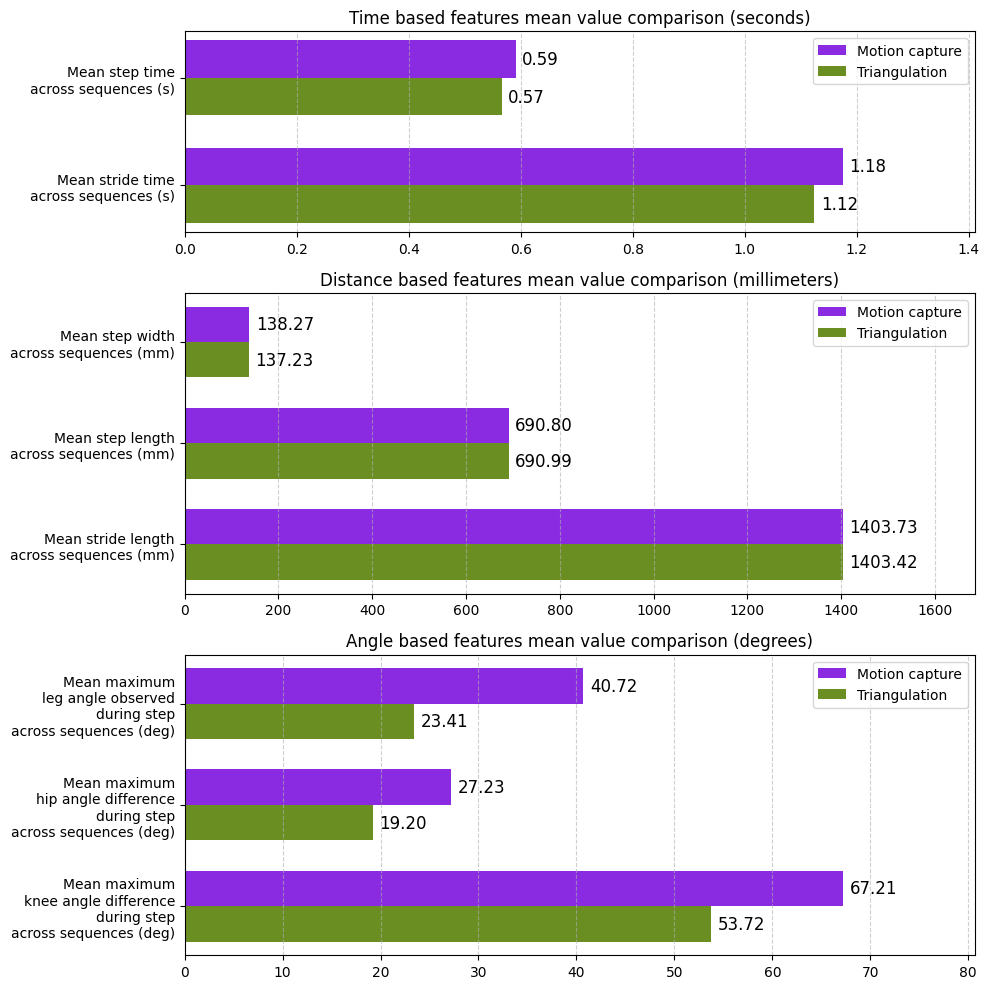

In [76]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

titles = [
    "Time based features mean value comparison (seconds)", 
    "Distance based features mean value comparison (millimeters)", 
    "Angle based features mean value comparison (degrees)", 
]

categories = [['Mean stride time\nacross sequences (s)', 'Mean step time\nacross sequences (s)'],
              ['Mean stride length\nacross sequences (mm)', 'Mean step length\nacross sequences (mm)', 'Mean step width\nacross sequences (mm)'],
              ['Mean maximum\nknee angle difference\nduring step\nacross sequences (deg)', 
               'Mean maximum\nhip angle difference\nduring step\nacross sequences (deg)', 
               'Mean maximum\nleg angle observed\nduring step\nacross sequences (deg)']]

mocap_val = [
   [mocap_stats.loc['total_mean_stride_time']['mean'],
   mocap_stats.loc['total_mean_step_times']['mean']],

   [mocap_stats.loc['total_mean_stride_dist']['mean'],
   mocap_stats.loc['total_mean_step_distance']['mean'],
   mocap_stats.loc['total_mean_step_width']['mean']],

   [mocap_stats.loc['total_mean_max_knee_angle_diff']['mean'],
   mocap_stats.loc['total_mean_max_hip_angle_diff']['mean'],
   mocap_stats.loc['total_mean_step_l_angle']['mean']],
  ]

triang_val = [
   [triang_stats.loc['total_mean_stride_time']['mean'],
   triang_stats.loc['total_mean_step_times']['mean']],

   [triang_stats.loc['total_mean_stride_dist']['mean'],
   triang_stats.loc['total_mean_step_distance']['mean'],
   triang_stats.loc['total_mean_step_width']['mean']],

   [triang_stats.loc['total_mean_max_knee_angle_diff']['mean'],
   triang_stats.loc['total_mean_max_hip_angle_diff']['mean'],
   triang_stats.loc['total_mean_step_l_angle']['mean']],
  ]

n_subplots = 3
bar_height = 0.35

fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(n_subplots, 1, height_ratios=[2, 3, 3]) 
axs = [fig.add_subplot(gs[i]) for i in range(3)]

    
for i in range(n_subplots):
    ax = axs[i]
    index = np.arange(len(categories[i]))
    ax.set_xlim(0, 1.2 * max(mocap_val[i]))
    
    bars1 = ax.barh(index + bar_height/2, mocap_val[i], height=bar_height, label='Motion capture', color='blueviolet')
    bars2 = ax.barh(index - bar_height/2, triang_val[i], height=bar_height, label='Triangulation', color='olivedrab')

    ax.grid(True, axis='x', linestyle='--', alpha=0.6)
    ax.set_yticks(index)
    ax.set_yticklabels(categories[i])

    for bar in bars1:
        width = bar.get_width()
        ax.text(width + 0.01 * max(mocap_val[i]), bar.get_y() + bar.get_height()/2, f'{width:.2f}', va='center', fontsize=12)
    for bar in bars2:
        width = bar.get_width()
        ax.text(width +  0.01 * max(mocap_val[i]), bar.get_y() + bar.get_height()/2, f'{width:.2f}', va='center', fontsize=12)


    ax.set_title(titles[i])
    ax.legend()

plt.tight_layout()
plt.savefig('./plots/gait_features_mean.png')
plt.show()


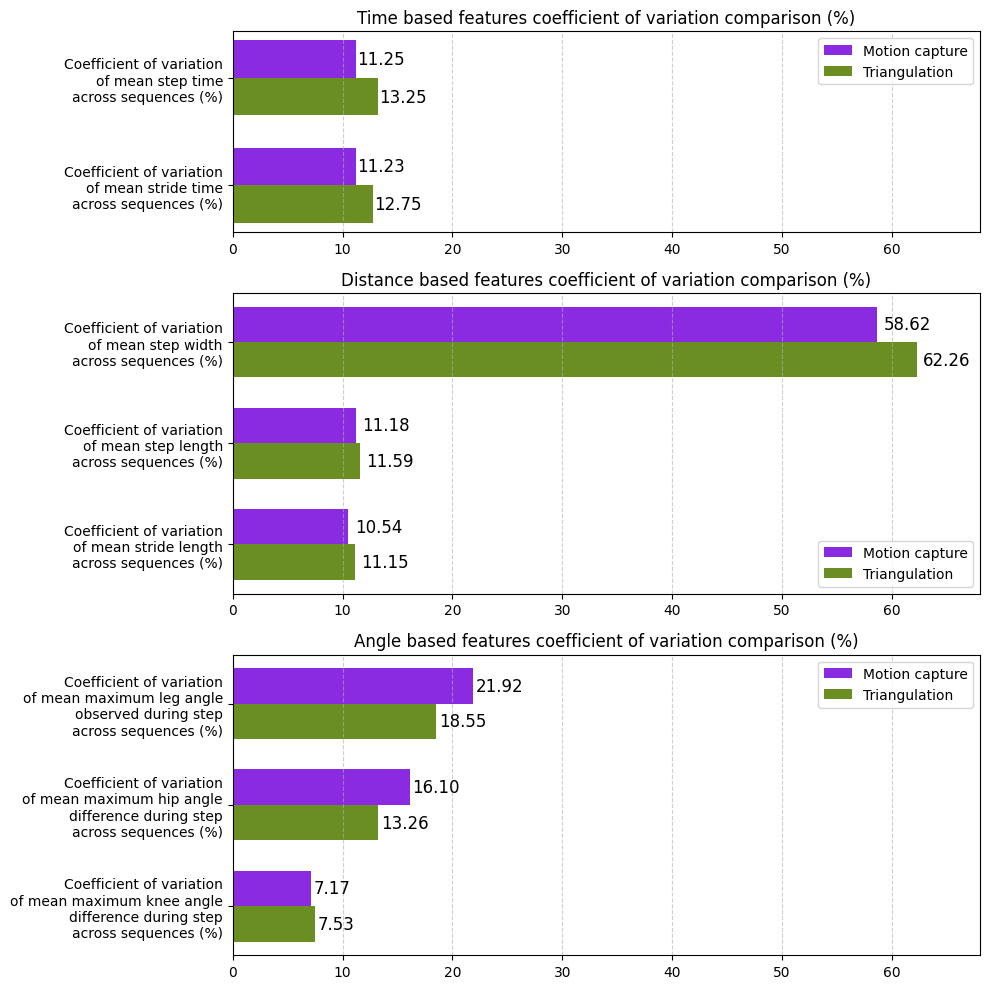

In [87]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

titles = [
    "Time based features coefficient of variation comparison (%)", 
    "Distance based features coefficient of variation comparison (%)", 
    "Angle based features coefficient of variation comparison (%)", 
]

categories = [['Coefficient of variation\nof mean stride time\nacross sequences (%)', 
               'Coefficient of variation\nof mean step time\nacross sequences (%)'],
              
              ['Coefficient of variation\nof mean stride length\nacross sequences (%)', 
               'Coefficient of variation\nof mean step length\nacross sequences (%)',
               'Coefficient of variation\nof mean step width\nacross sequences (%)'],
              
              ['Coefficient of variation\nof mean maximum knee angle\ndifference during step\nacross sequences (%)',
               'Coefficient of variation\nof mean maximum hip angle\ndifference during step\nacross sequences (%)',
               'Coefficient of variation\nof mean maximum leg angle\nobserved during step\nacross sequences (%)']]


mocap_val = [
    [mocap_stats.loc['total_mean_stride_time']['cv'],
    mocap_stats.loc['total_mean_step_times']['cv']],
    
    [mocap_stats.loc['total_mean_stride_dist']['cv'],
    mocap_stats.loc['total_mean_step_distance']['cv'],
    mocap_stats.loc['total_mean_step_width']['cv']],
    
    [mocap_stats.loc['total_mean_max_knee_angle_diff']['cv'],
    mocap_stats.loc['total_mean_max_hip_angle_diff']['cv'],
    mocap_stats.loc['total_mean_step_l_angle']['cv']],
    ]

triang_val = [
    [triang_stats.loc['total_mean_stride_time']['cv'],
    triang_stats.loc['total_mean_step_times']['cv']],
    
    [triang_stats.loc['total_mean_stride_dist']['cv'],
    triang_stats.loc['total_mean_step_distance']['cv'],
    triang_stats.loc['total_mean_step_width']['cv']],
    
    [triang_stats.loc['total_mean_max_knee_angle_diff']['cv'],
    triang_stats.loc['total_mean_max_hip_angle_diff']['cv'],
    triang_stats.loc['total_mean_step_l_angle']['cv']],
    ]

n_subplots = 3
bar_height = 0.35

fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(n_subplots, 1, height_ratios=[2, 3, 3]) 
axs = [fig.add_subplot(gs[i]) for i in range(3)]

    
for i in range(n_subplots):
    ax = axs[i]
    index = np.arange(len(categories[i]))
    ax.set_xlim(0, 68)
    
    bars1 = ax.barh(index + bar_height/2, mocap_val[i], height=bar_height, label='Motion capture', color='blueviolet')
    bars2 = ax.barh(index - bar_height/2, triang_val[i], height=bar_height, label='Triangulation', color='olivedrab')

    ax.grid(True, axis='x', linestyle='--', alpha=0.6)
    ax.set_yticks(index)
    ax.set_yticklabels(categories[i])

    for bar in bars1:
        width = bar.get_width()
        ax.text(width + 0.01 * max(mocap_val[i]), bar.get_y() + bar.get_height()/2, f'{width:.2f}', va='center', fontsize=12)
    for bar in bars2:
        width = bar.get_width()
        ax.text(width +  0.01 * max(mocap_val[i]), bar.get_y() + bar.get_height()/2, f'{width:.2f}', va='center', fontsize=12)


    ax.set_title(titles[i])
    ax.legend()

plt.tight_layout()
plt.savefig('./plots/gait_features_cv.png')
plt.show()
